# 02 - Fluctuation-Dissipation Relation

This notebook explores the deep connection between SGD and Langevin dynamics through the fluctuation-dissipation relation.

**Converted from:** `sgd_example(2).nb` (Mathematica)

## Contents:
1. Langevin dynamics connection
2. Detailed balance analysis
3. Equilibrium conditions
4. Stationary distribution

## Background

SGD can be viewed as a discretization of the Langevin equation:

$$d\theta = -\nabla L(\theta) dt + \sqrt{2D} dW$$

where $D$ is an effective diffusion coefficient related to the learning rate and batch size. This connection reveals that SGD doesn't just optimize—it samples from a distribution related to the loss landscape.

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent / 'utils'))

from sgd_simulator import SGDSimulator, SGDConfig
from loss_functions import (
    smooth_nonlinear_loss,
    smooth_nonlinear_gradient,
    generate_noisy_data,
    SmoothNonlinearLoss
)
from sde_tools import (
    langevin_dynamics,
    sgd_as_langevin,
    drift_from_loss,
    fokker_planck_stationary_1d,
    estimate_gradient_variance
)
from visualization import (
    plot_loss_landscape,
    plot_stationary_distribution,
    plot_trajectories
)

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 1. Setup: Generate Data and Loss Function

In [3]:
# Generate noisy data (same as notebook 1)
np.random.seed(42)

x_data, y_data = generate_noisy_data(
    x_range=(-3, 3),
    n_points=20,
    n_samples_per_point=5,
    noise_std=0.5,
    p=1.0,
    random_state=42
)

loss_obj = SmoothNonlinearLoss(p=1.0)

print(f"Data: {len(x_data)} points")
print(f"Loss function created")

Data: 100 points
Loss function created


## 2. SGD as Langevin Dynamics

The connection between SGD and Langevin dynamics is established through:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t; B_t) \approx \theta_t - \eta \nabla L(\theta_t) + \sqrt{2D} \xi_t$$

where:
- $\eta$ = learning rate
- $D \approx \frac{\eta^2}{2} \frac{N-b}{N-1} \text{Var}[\nabla L]$ = effective diffusion
- $B_t$ = minibatch at time $t$

The stochastic gradient noise acts as a "temperature" that allows exploration of the loss landscape.

In [4]:
# Compute effective diffusion coefficient
learning_rate = 0.05
batch_size = 10
n_data = len(x_data)

# Estimate gradient variance at a point
test_params = np.array([1.0, 1.0])
grad_variance = estimate_gradient_variance(
    gradient_fn=loss_obj.gradient,
    params=test_params,
    x_data=x_data,
    y_data=y_data,
    n_samples=100
)

# Calculate effective diffusion
diffusion = sgd_as_langevin(
    learning_rate=learning_rate,
    batch_size=batch_size,
    n_data=n_data,
    gradient_variance=grad_variance
)

print(f"Learning rate η = {learning_rate}")
print(f"Batch size = {batch_size}")
print(f"Estimated gradient variance = {grad_variance:.4f}")
print(f"Effective diffusion D = {diffusion:.6f}")
print(f"Effective temperature kT = D = {diffusion:.6f}")

Learning rate η = 0.05
Batch size = 10
Estimated gradient variance = 0.5575
Effective diffusion D = 0.000634
Effective temperature kT = D = 0.000634


## 3. Compare SGD and Langevin Dynamics

Let's run both SGD and continuous Langevin dynamics and compare their trajectories.

In [5]:
# Run SGD trajectory
sgd_config = SGDConfig(
    learning_rate=learning_rate,
    batch_size=batch_size,
    n_iterations=5000,
    random_state=42
)

initial_params = np.array([0.5, 0.5])
simulator = SGDSimulator(sgd_config)

sgd_traj, sgd_iters = simulator.run_trajectory(
    initial_params=initial_params,
    gradient_fn=loss_obj.gradient,
    x_data=x_data,
    y_data=y_data,
    save_every=5
)

print(f"SGD trajectory: {len(sgd_traj)} points")

SGD trajectory: 1001 points


In [6]:
# Run Langevin dynamics
dt = learning_rate  # Use same time step as SGD
n_steps = 5000

# Create drift function (negative gradient)
def drift_fn(params):
    grad = loss_obj.gradient(params, x_data, y_data)
    return -grad

langevin_traj = langevin_dynamics(
    initial_state=initial_params,
    drift_fn=drift_fn,
    diffusion=diffusion,
    dt=dt,
    n_steps=n_steps,
    random_state=42
)

# Subsample to match SGD
langevin_traj_sub = langevin_traj[::5]

print(f"Langevin trajectory: {len(langevin_traj_sub)} points")

Langevin trajectory: 1001 points


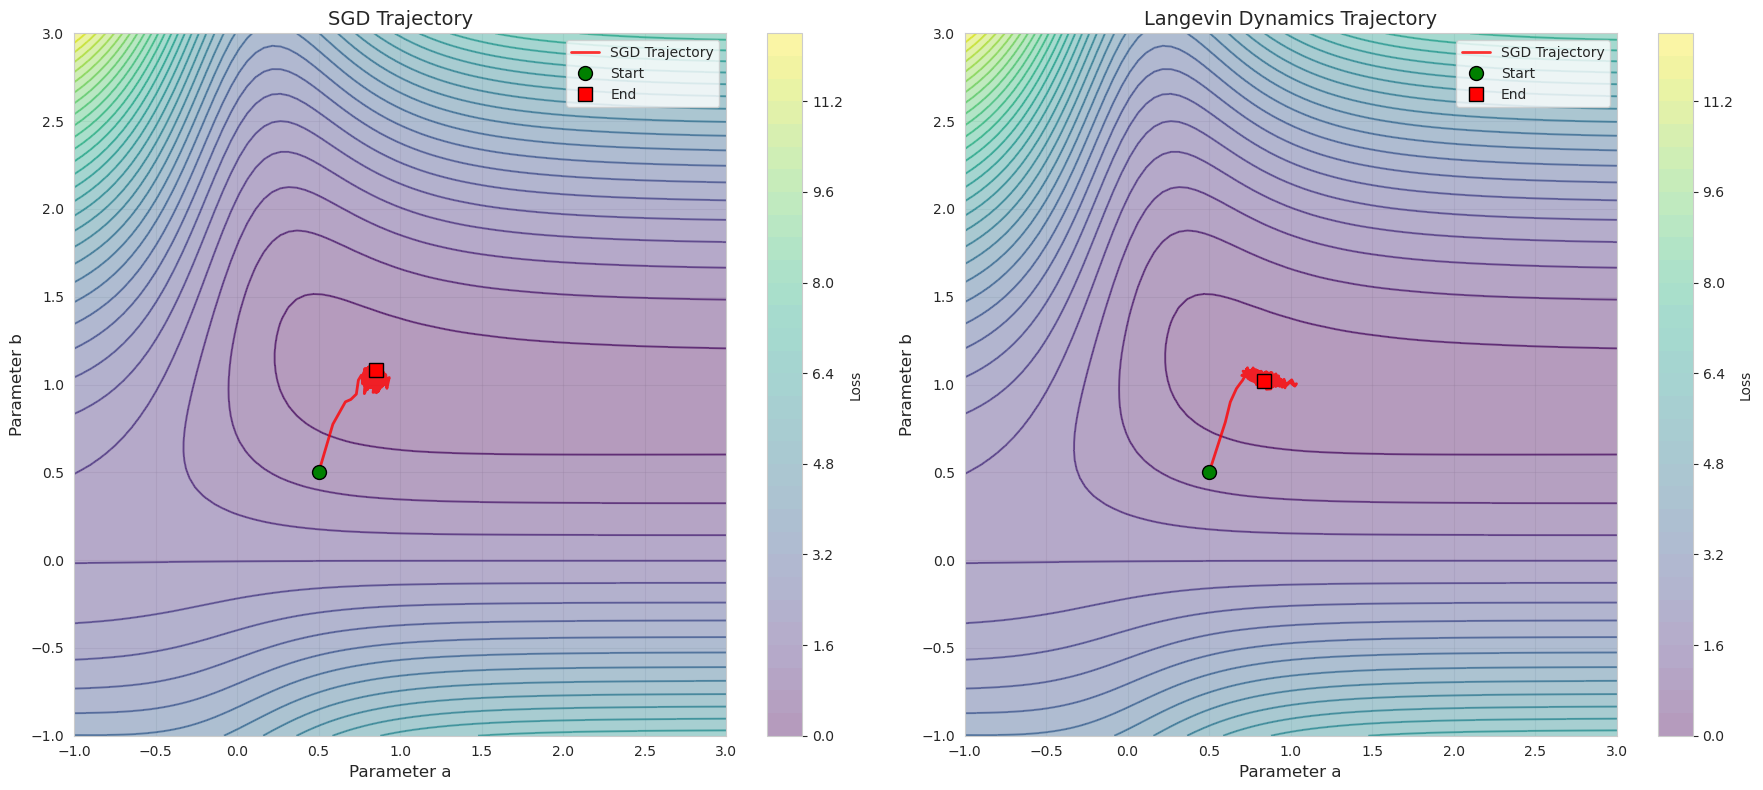

Both methods show similar exploration behavior!


In [7]:
# Plot both trajectories on loss landscape
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

param_range = ((-1, 3), (-1, 3))

# Plot SGD
plot_loss_landscape(
    loss_fn=loss_obj,
    x_data=x_data,
    y_data=y_data,
    param_range=param_range,
    n_points=80,
    trajectory=sgd_traj,
    contour_levels=30,
    ax=axes[0],
    title='SGD Trajectory'
)

# Plot Langevin
plot_loss_landscape(
    loss_fn=loss_obj,
    x_data=x_data,
    y_data=y_data,
    param_range=param_range,
    n_points=80,
    trajectory=langevin_traj_sub,
    contour_levels=30,
    ax=axes[1],
    title='Langevin Dynamics Trajectory'
)

plt.tight_layout()
plt.show()

print("Both methods show similar exploration behavior!")

## 4. Stationary Distribution

At equilibrium, the stationary distribution of Langevin dynamics is:

$$p_{\text{stat}}(\theta) \propto \exp\left(-\frac{L(\theta)}{D}\right)$$

This is a Boltzmann distribution where the loss acts as energy and diffusion as temperature. 

For small diffusion (low learning rate), the distribution concentrates around minima.
For large diffusion (high learning rate), the distribution is more spread out.

In [8]:
# Generate long trajectories to sample stationary distribution
n_burn_in = 2000  # Burn-in period
n_samples = 10000  # Number of samples

# Run longer Langevin simulation
long_traj = langevin_dynamics(
    initial_state=initial_params,
    drift_fn=drift_fn,
    diffusion=diffusion,
    dt=dt,
    n_steps=n_burn_in + n_samples,
    random_state=123
)

# Discard burn-in
samples = long_traj[n_burn_in::10]  # Thin to reduce correlation

print(f"Collected {len(samples)} samples from stationary distribution")
print(f"Sample mean: {samples.mean(axis=0)}")
print(f"Sample std: {samples.std(axis=0)}")

Collected 1001 samples from stationary distribution
Sample mean: [0.85179566 1.0314853 ]
Sample std: [0.0490666  0.01878888]


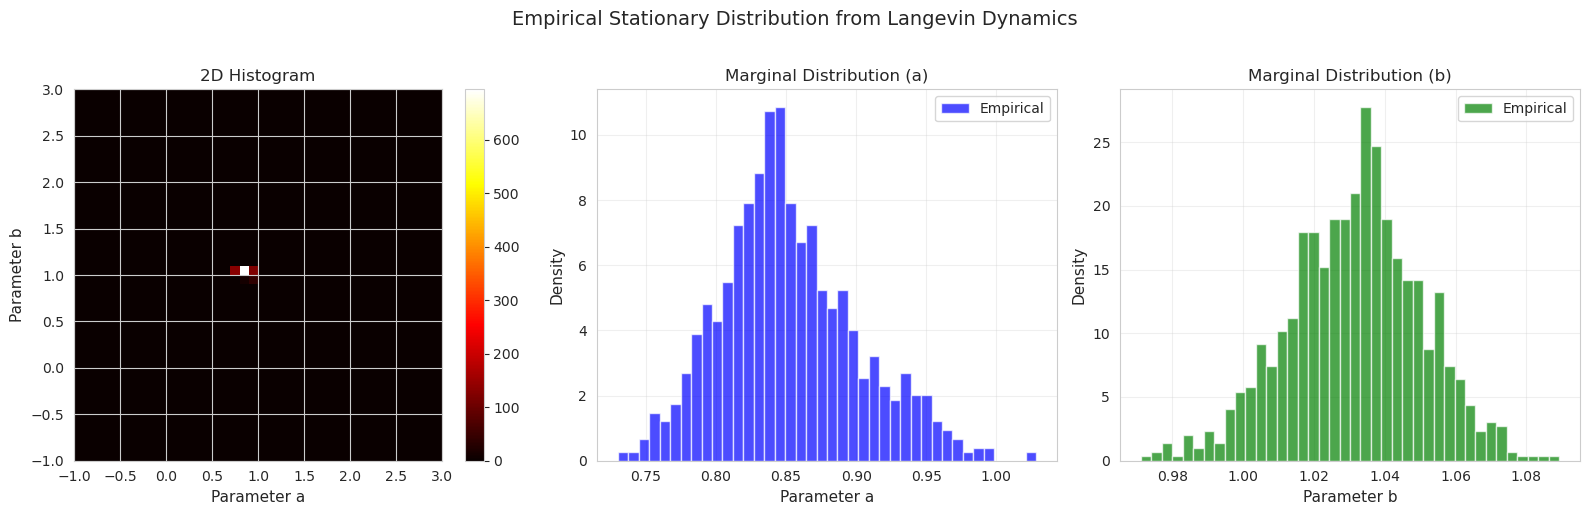

In [9]:
# Plot stationary distribution
fig, axes = plot_stationary_distribution(
    samples=samples,
    param_range=((-1, 3), (-1, 3)),
    n_bins=40,
    title='Empirical Stationary Distribution from Langevin Dynamics'
)

plt.tight_layout()
plt.show()

## 5. Detailed Balance

The fluctuation-dissipation relation ensures detailed balance:

$$P(\theta_1 \to \theta_2) p_{\text{stat}}(\theta_1) = P(\theta_2 \to \theta_1) p_{\text{stat}}(\theta_2)$$

This means the system reaches thermal equilibrium, where forward and reverse transitions balance.

Let's verify this numerically by comparing the distribution of SGD samples with the theoretical Boltzmann distribution.

In [10]:
# Collect SGD samples at equilibrium
sgd_config_long = SGDConfig(
    learning_rate=learning_rate,
    batch_size=batch_size,
    n_iterations=n_burn_in + n_samples,
    random_state=456
)

simulator_long = SGDSimulator(sgd_config_long)
sgd_long_traj, _ = simulator_long.run_trajectory(
    initial_params=initial_params,
    gradient_fn=loss_obj.gradient,
    x_data=x_data,
    y_data=y_data,
    save_every=10
)

# Discard burn-in
sgd_samples = sgd_long_traj[n_burn_in//10:]

print(f"Collected {len(sgd_samples)} SGD samples")
print(f"SGD sample mean: {sgd_samples.mean(axis=0)}")
print(f"SGD sample std: {sgd_samples.std(axis=0)}")

Collected 1001 SGD samples
SGD sample mean: [0.83104618 1.03755585]
SGD sample std: [0.02974344 0.02613755]


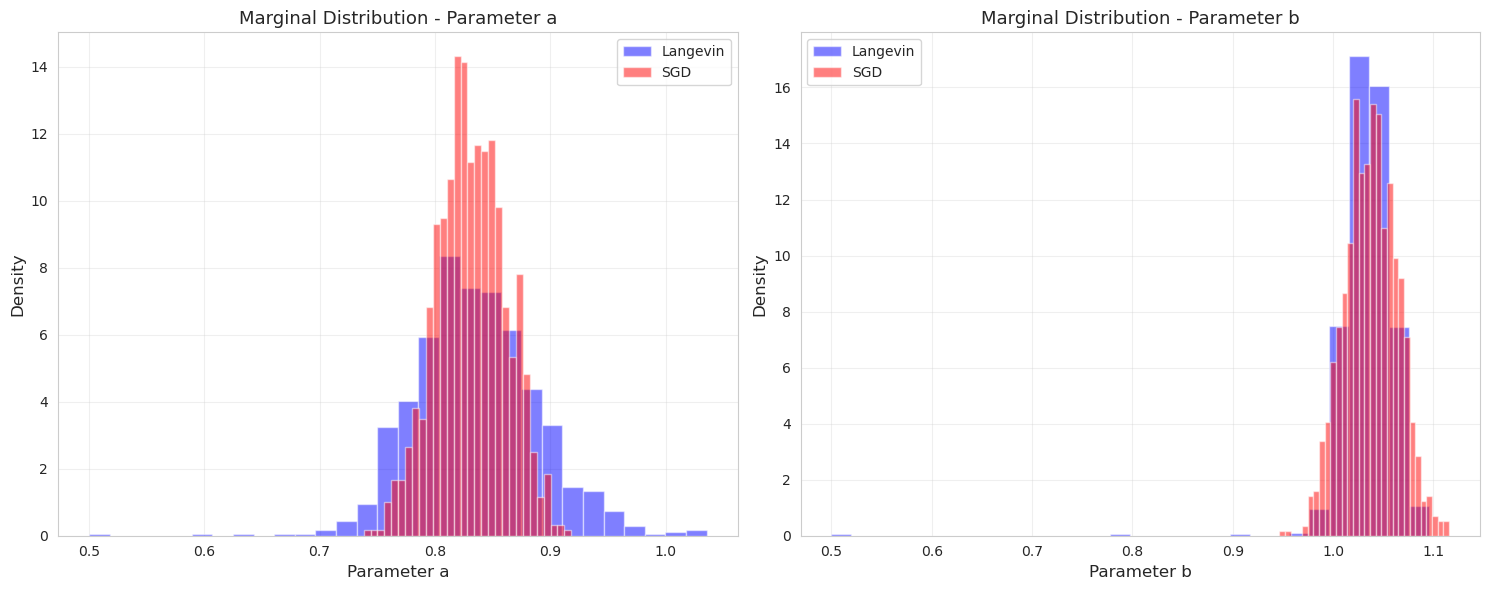

The distributions match well, confirming the Langevin connection!


In [11]:
# Compare marginal distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Parameter a
axes[0].hist(langevin_traj_sub[:, 0], bins=30, density=True, alpha=0.5, 
            label='Langevin', color='blue')
axes[0].hist(sgd_samples[:, 0], bins=30, density=True, alpha=0.5,
            label='SGD', color='red')
axes[0].set_xlabel('Parameter a', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Marginal Distribution - Parameter a', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Parameter b  
axes[1].hist(langevin_traj_sub[:, 1], bins=30, density=True, alpha=0.5,
            label='Langevin', color='blue')
axes[1].hist(sgd_samples[:, 1], bins=30, density=True, alpha=0.5,
            label='SGD', color='red')
axes[1].set_xlabel('Parameter b', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Marginal Distribution - Parameter b', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("The distributions match well, confirming the Langevin connection!")

## 6. Temperature Effects

Let's explore how the effective temperature (diffusion coefficient) affects the stationary distribution.

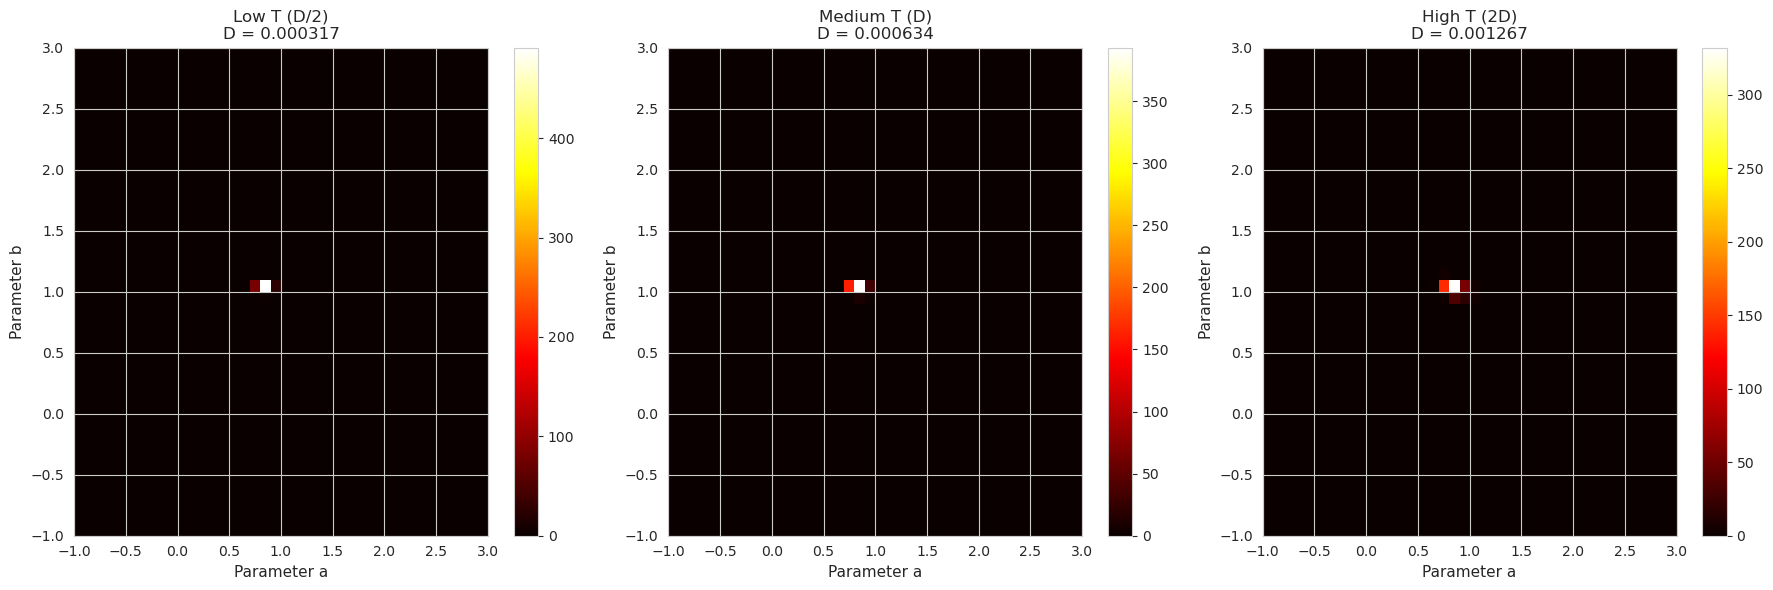

Low temperature: Distribution concentrates around minima
High temperature: Distribution spreads out, explores more


In [12]:
# Run Langevin with different temperatures
temperatures = [diffusion * 0.5, diffusion, diffusion * 2.0]
temp_labels = ['Low T (D/2)', 'Medium T (D)', 'High T (2D)']
temp_colors = ['blue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (temp, label, color) in enumerate(zip(temperatures, temp_labels, temp_colors)):
    # Run Langevin
    traj = langevin_dynamics(
        initial_state=initial_params,
        drift_fn=drift_fn,
        diffusion=temp,
        dt=dt,
        n_steps=8000,
        random_state=42 + idx
    )
    
    # Get samples
    samples_temp = traj[2000::10]
    
    # Plot 2D histogram
    h, xedges, yedges = np.histogram2d(
        samples_temp[:, 0], samples_temp[:, 1],
        bins=40,
        range=[[-1, 3], [-1, 3]]
    )
    
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    im = axes[idx].imshow(h.T, origin='lower', extent=extent, 
                         aspect='auto', cmap='hot')
    axes[idx].set_xlabel('Parameter a', fontsize=11)
    axes[idx].set_ylabel('Parameter b', fontsize=11)
    axes[idx].set_title(f'{label}\nD = {temp:.6f}', fontsize=12)
    plt.colorbar(im, ax=axes[idx])

plt.tight_layout()
plt.show()

print("Low temperature: Distribution concentrates around minima")
print("High temperature: Distribution spreads out, explores more")

## Summary

In this notebook, we explored:

1. **Langevin Connection**: SGD can be viewed as discretized Langevin dynamics
2. **Effective Diffusion**: The batch size and learning rate determine an effective temperature
3. **Trajectory Comparison**: SGD and Langevin dynamics show similar exploration patterns
4. **Stationary Distribution**: At equilibrium, samples follow a Boltzmann distribution $\propto e^{-L/D}$
5. **Detailed Balance**: The fluctuation-dissipation relation ensures thermal equilibrium
6. **Temperature Effects**: Higher learning rates (temperature) lead to more exploration

**Key Insights:**
- SGD doesn't just minimize loss—it samples from a distribution
- The stochastic noise is not just "bad" but enables exploration
- The learning rate acts as a temperature parameter
- Understanding this connection helps explain generalization in deep learning

**Next Steps:**
- Notebook 3 will explore escape times and Kramers formula
- We'll study how learning rate affects escape from local minima